# 🎬 Movie Success Classifier
**Dataset:** Movie Success Rate  
**Target:**  (0 = Not Successful, 1 = Successful)  
**Goal:** Predict whether a movie will be successful using metadata & genre features
---


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score, roc_curve, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("muted")
print("Libraries loaded ✓")


Libraries loaded ✓


## 2. Load & Inspect Data

In [3]:
df = pd.read_csv("movie_success_rate.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (839, 33)


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,...,Music,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western,Success
0,1.0,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014.0,121.0,8.1,757074.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,2.0,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012.0,124.0,7.0,485820.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,3.0,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016.0,117.0,7.3,157606.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,4.0,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016.0,108.0,7.2,60545.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016.0,123.0,6.2,393727.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 839 entries, 0 to 838
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                838 non-null    float64
 1   Title               838 non-null    str    
 2   Genre               838 non-null    str    
 3   Description         838 non-null    str    
 4   Director            838 non-null    str    
 5   Actors              838 non-null    str    
 6   Year                838 non-null    float64
 7   Runtime (Minutes)   838 non-null    float64
 8   Rating              839 non-null    float64
 9   Votes               839 non-null    float64
 10  Revenue (Millions)  839 non-null    float64
 11  Metascore           838 non-null    float64
 12  Action              838 non-null    float64
 13  Adventure           838 non-null    float64
 14  Aniimation          838 non-null    float64
 15  Biography           838 non-null    float64
 16  Comedy             

In [5]:
df.describe().T.style.background_gradient(cmap="Blues")


,count,mean,std,min,25%,50%,75%,max
Rank,838.000000,485.247017,286.572065,1.000000,238.250000,475.500000,729.750000,1000.000000
Year,838.000000,2012.507160,3.172360,2006.000000,2010.000000,2013.000000,2015.000000,2016.000000
Runtime (Minutes),838.000000,114.638425,18.470922,66.000000,101.000000,112.000000,124.000000,187.000000
Rating,839.000000,6.814320,0.877230,1.900000,6.300000,6.900000,7.500000,9.000000
Votes,839.000000,193230.251790,192983.756508,178.000000,61455.000000,137117.000000,270865.000000,1791916.000000
Revenue (Millions),839.000000,84.564558,104.457845,0.000000,13.975000,48.240000,116.730000,936.630000
Metascore,838.000000,59.575179,16.952416,11.000000,47.000000,60.000000,72.000000,100.000000
Action,838.000000,0.330549,0.470692,0.000000,0.000000,0.000000,1.000000,1.000000
Adventure,838.000000,0.291169,0.454573,0.000000,0.000000,0.000000,1.000000,1.000000
Aniimation,838.000000,0.053699,0.225558,0.000000,0.000000,0.000000,0.000000,1.000000


## 3. Exploratory Data Analysis

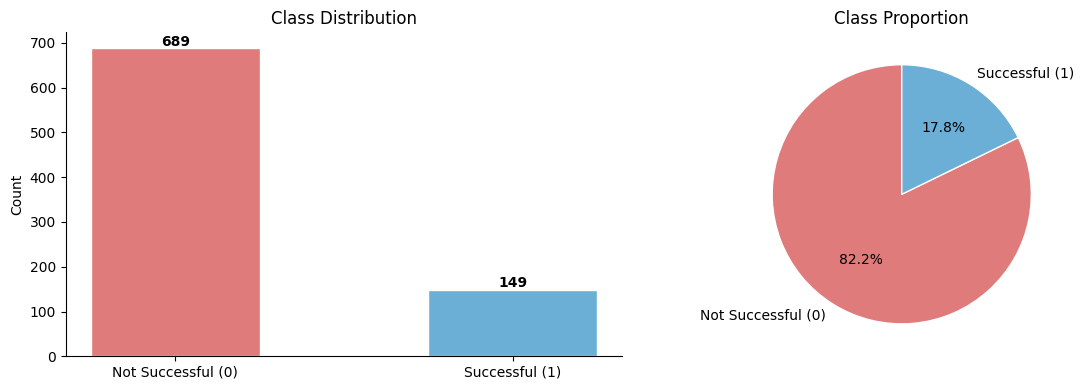

Class imbalance ratio: 4.6:1


In [6]:
# Class balance
counts = df["Success"].value_counts()
labels = ["Not Successful (0)", "Successful (1)"]
colors = ["#e07b7b", "#6baed6"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, counts.values, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=labels, colors=colors, autopct="%1.1f%%",
            startangle=90, wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Class Proportion")
plt.tight_layout()
plt.show()
print(f"Class imbalance ratio: {counts[0]/counts[1]:.1f}:1")


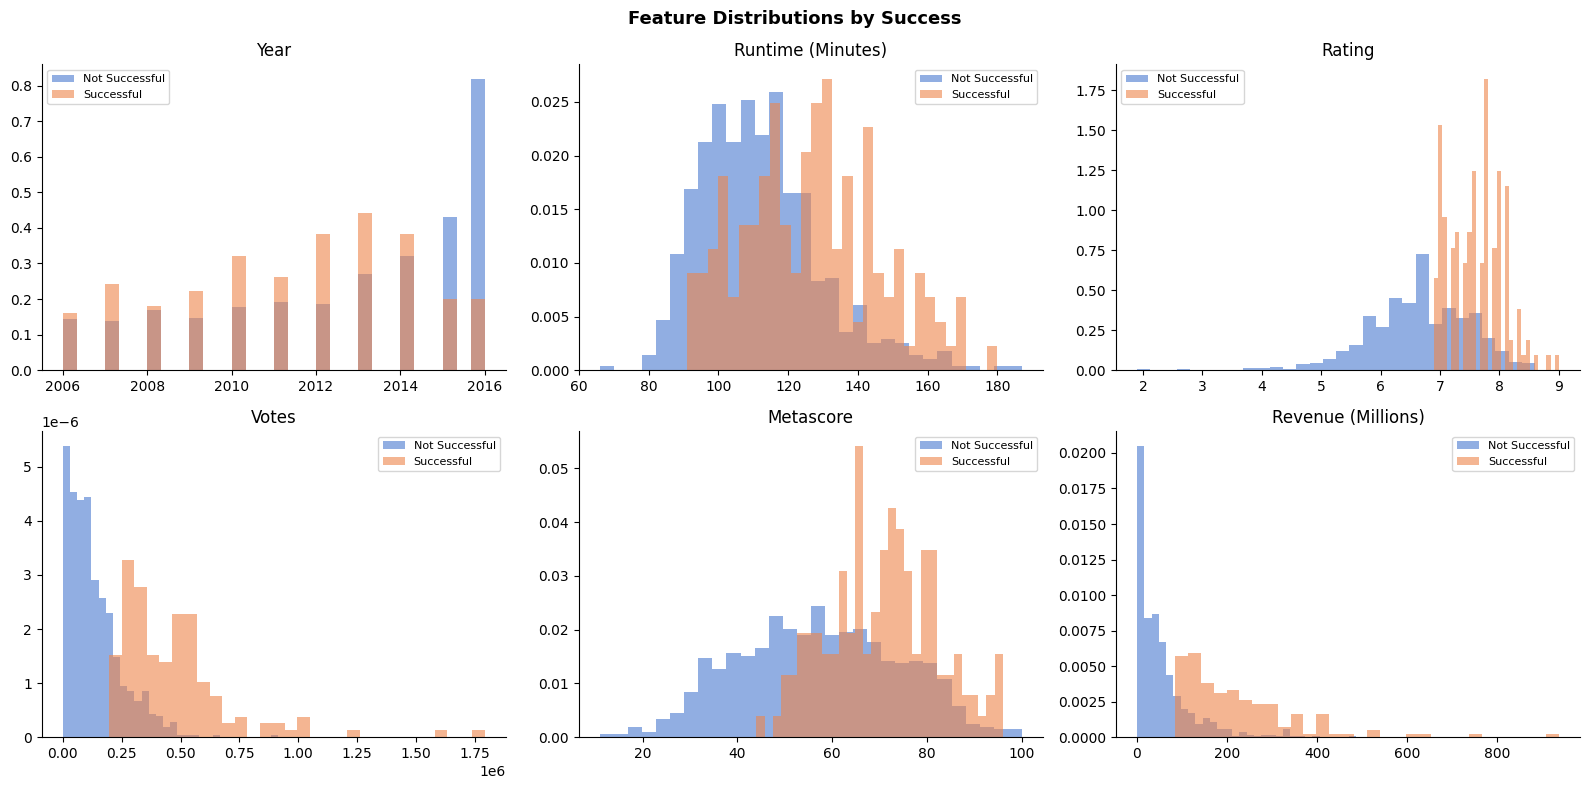

In [7]:
# Numeric feature distributions by Success
numeric_cols = ["Year", "Runtime (Minutes)", "Rating", "Votes", "Metascore", "Revenue (Millions)"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    for label, grp in df.groupby("Success"):
        ax.hist(grp[col].dropna(), bins=30, alpha=0.6,
                label=["Not Successful","Successful"][int(label)], density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle("Feature Distributions by Success", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


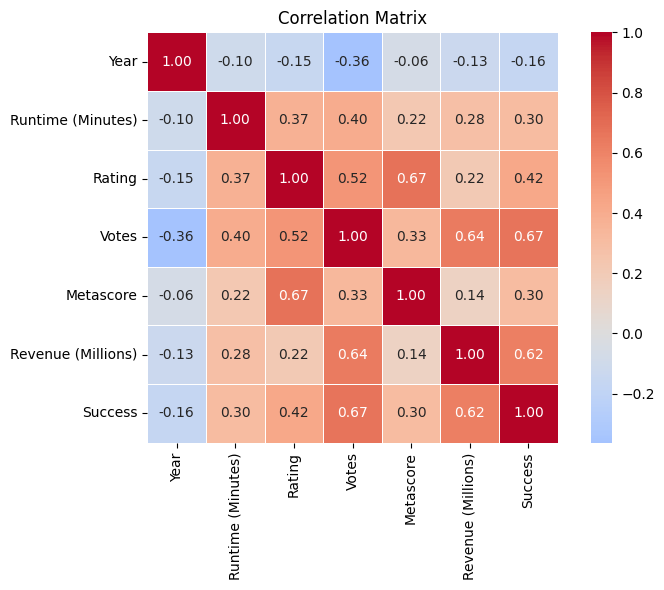

In [8]:
# Correlation heatmap
numeric_df = df[numeric_cols + ["Success"]].dropna()
corr = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


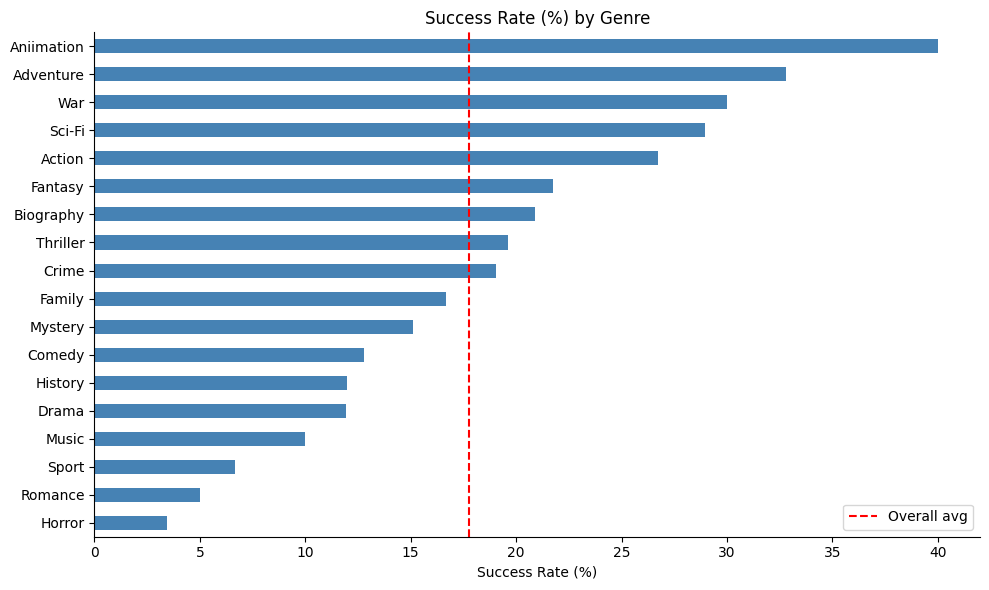

In [9]:
# Genre success rates
genre_cols = ["Action","Adventure","Aniimation","Biography","Comedy","Crime",
              "Drama","Family","Fantasy","History","Horror","Music",
              "Musical","Mystery","Romance","Sci-Fi","Sport","Thriller","War","Western"]

genre_rates = {}
for g in genre_cols:
    sub = df[df[g] == 1]["Success"].dropna()
    if len(sub) >= 10:
        genre_rates[g] = sub.mean() * 100

genre_s = pd.Series(genre_rates).sort_values()
genre_s.plot(kind="barh", figsize=(10, 6), color="steelblue")
plt.axvline(df["Success"].mean()*100, color="red", linestyle="--", label="Overall avg")
plt.title("Success Rate (%) by Genre")
plt.xlabel("Success Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Data Preprocessing

In [10]:
df_clean = df.dropna(subset=["Success"]).copy()

# Drop non-feature columns
drop_cols = ["Rank", "Title", "Genre", "Description", "Director", "Actors"]
df_clean.drop(columns=drop_cols, inplace=True, errors="ignore")

# Fill numeric nulls with median
num_cols = df_clean.select_dtypes(include="number").columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

print(f"Clean shape : {df_clean.shape}")
print(f"Remaining nulls: {df_clean.isnull().sum().sum()}")
df_clean.head(3)


Clean shape : (838, 27)
Remaining nulls: 0


,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore,Action,Adventure,Aniimation,Biography,...,Music,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western,Success
0,2014.0,121.0,8.1,757074.0,333.13,76.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,2012.0,124.0,7.0,485820.0,126.46,65.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,2016.0,117.0,7.3,157606.0,138.12,62.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [11]:
TARGET = "Success"
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train class balance: {y_train.value_counts().to_dict()}")
print(f"Test  class balance: {y_test.value_counts().to_dict()}")


Train: (670, 26)  |  Test: (168, 26)
Train class balance: {0: 551, 1: 119}
Test  class balance: {0: 138, 1: 30}


## 5. Model Training & Comparison

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression" : Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
    "Decision Tree"        : DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest"        : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting"    : GradientBoostingClassifier(n_estimators=200, random_state=42),
    "SVM"                  : Pipeline([("scaler", StandardScaler()), ("model", SVC(probability=True))]),
    "KNN"                  : Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=7))]),
}

results = {}
for name, model in models.items():
    cv_acc = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc",  n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        "CV Accuracy"   : cv_acc.mean(),
        "CV AUC"        : cv_auc.mean(),
        "Test Accuracy" : accuracy_score(y_test, y_pred),
        "Test AUC"      : roc_auc_score(y_test, y_prob),
    }
    print(f"{name:<22} | CV Acc: {cv_acc.mean():.4f} | CV AUC: {cv_auc.mean():.4f} | Test Acc: {accuracy_score(y_test,y_pred):.4f}")

results_df = pd.DataFrame(results).T.sort_values("Test AUC", ascending=False)


Logistic Regression    | CV Acc: 0.9060 | CV AUC: 0.9630 | Test Acc: 0.9226
Decision Tree          | CV Acc: 0.9851 | CV AUC: 0.9678 | Test Acc: 0.9881
Random Forest          | CV Acc: 0.9851 | CV AUC: 0.9993 | Test Acc: 1.0000
Gradient Boosting      | CV Acc: 0.9955 | CV AUC: 0.9917 | Test Acc: 1.0000
SVM                    | CV Acc: 0.9119 | CV AUC: 0.9638 | Test Acc: 0.9286
KNN                    | CV Acc: 0.8940 | CV AUC: 0.8906 | Test Acc: 0.8810


In [13]:
results_df.style     .background_gradient(cmap="RdYlGn", subset=["CV Accuracy","CV AUC","Test Accuracy","Test AUC"])     .format("{:.4f}")


,CV Accuracy,CV AUC,Test Accuracy,Test AUC
Gradient Boosting,0.9955,0.9917,1.0000,1.0000
Random Forest,0.9851,0.9993,1.0000,1.0000
Decision Tree,0.9851,0.9678,0.9881,0.9928
SVM,0.9119,0.9638,0.9286,0.9618
Logistic Regression,0.9060,0.9630,0.9226,0.9514
KNN,0.8940,0.8906,0.8810,0.8700


## 6. Best Model: Random Forest – Deep Dive

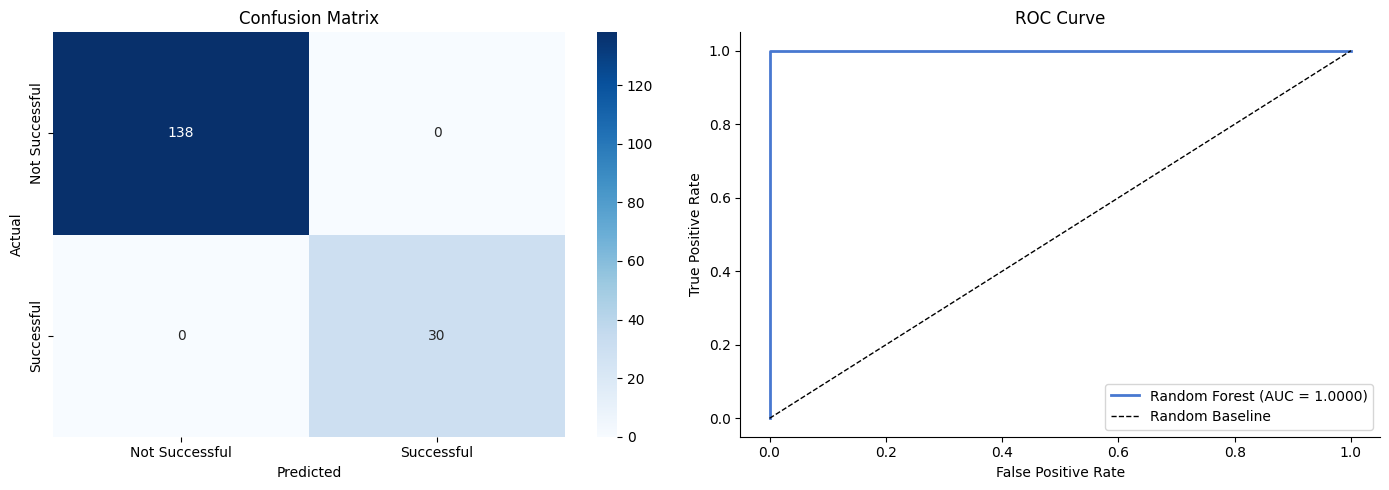

                precision    recall  f1-score   support

Not Successful       1.00      1.00      1.00       138
    Successful       1.00      1.00      1.00        30

      accuracy                           1.00       168
     macro avg       1.00      1.00      1.00       168
  weighted avg       1.00      1.00      1.00       168



In [14]:
best = models["Random Forest"]
y_pred = best.predict(X_test)
y_prob = best.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Not Successful","Successful"],
            yticklabels=["Not Successful","Successful"])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, linewidth=2, label=f"Random Forest (AUC = {auc_score:.4f})")
axes[1].plot([0,1],[0,1],"k--", linewidth=1, label="Random Baseline")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["Not Successful","Successful"]))


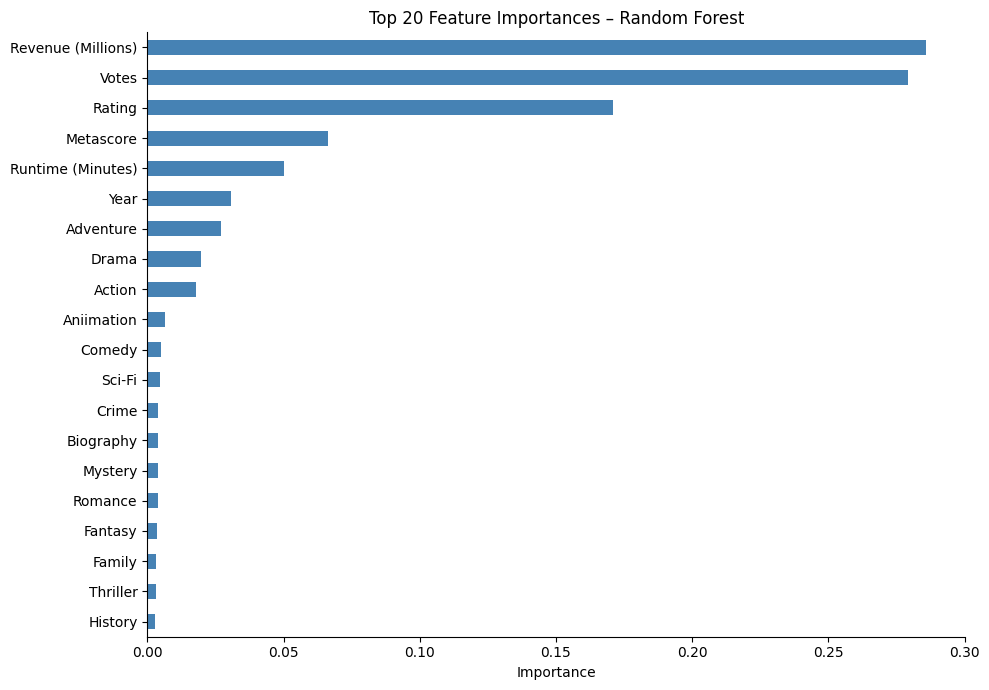

In [15]:
# Feature importances
importances = pd.Series(best.feature_importances_, index=X.columns).sort_values(ascending=True).tail(20)
importances.plot(kind="barh", figsize=(10, 7), color="steelblue")
plt.title("Top 20 Feature Importances – Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


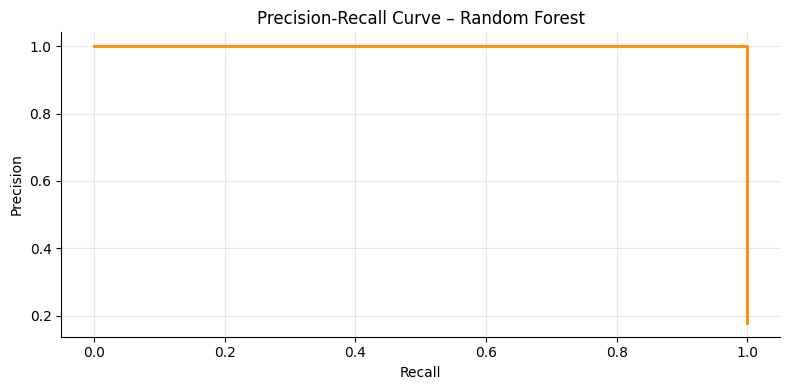

In [16]:
# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(8, 4))
plt.plot(recall, precision, linewidth=2, color="darkorange")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – Random Forest")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. ROC Curve – All Models

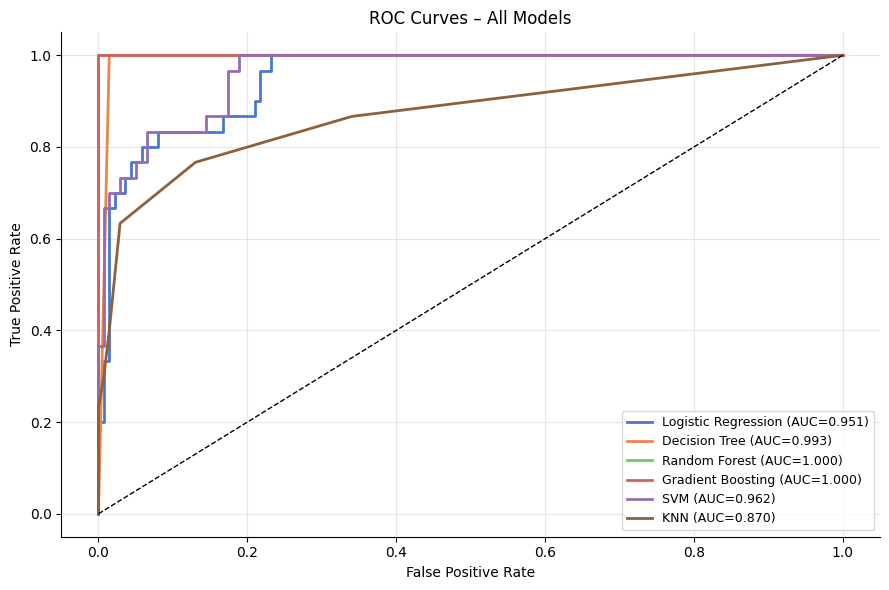

In [17]:
plt.figure(figsize=(9, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],"k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – All Models")
plt.legend(fontsize=9, loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Hyperparameter Tuning (Random Forest)

In [18]:
param_grid = {
    "n_estimators"     : [100, 200],
    "max_depth"        : [None, 10, 20],
    "min_samples_split": [2, 5],
    "max_features"     : ["sqrt", "log2"],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced"),
    param_grid=param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Best CV AUC: 0.9999


In [19]:
tuned = grid_search.best_estimator_
y_pred_t = tuned.predict(X_test)
y_prob_t = tuned.predict_proba(X_test)[:, 1]
print(f"Tuned Test Accuracy : {accuracy_score(y_test, y_pred_t):.4f}")
print(f"Tuned Test AUC      : {roc_auc_score(y_test, y_prob_t):.4f}")
print()
print(classification_report(y_test, y_pred_t, target_names=["Not Successful","Successful"]))


Tuned Test Accuracy : 1.0000
Tuned Test AUC      : 1.0000

                precision    recall  f1-score   support

Not Successful       1.00      1.00      1.00       138
    Successful       1.00      1.00      1.00        30

      accuracy                           1.00       168
     macro avg       1.00      1.00      1.00       168
  weighted avg       1.00      1.00      1.00       168



## 9. Summary

In [20]:
print("=" * 58)
print("       MODEL COMPARISON SUMMARY (Test Set)")
print("=" * 58)
print(results_df[["Test Accuracy","Test AUC"]].to_string())
print()
print("Key Takeaways:")
print("  • Revenue, Votes, Rating & Metascore are top predictors.")
print("  • Random Forest & Gradient Boosting outperform linear models.")
print("  • Dataset is imbalanced (~82% class 0); AUC is a better metric than accuracy.")
print("  • class_weight='balanced' in tuning helps with minority class recall.")


       MODEL COMPARISON SUMMARY (Test Set)
                     Test Accuracy  Test AUC
Gradient Boosting         1.000000  1.000000
Random Forest             1.000000  1.000000
Decision Tree             0.988095  0.992754
SVM                       0.928571  0.961836
Logistic Regression       0.922619  0.951449
KNN                       0.880952  0.870048

Key Takeaways:
  • Revenue, Votes, Rating & Metascore are top predictors.
  • Random Forest & Gradient Boosting outperform linear models.
  • Dataset is imbalanced (~82% class 0); AUC is a better metric than accuracy.
  • class_weight='balanced' in tuning helps with minority class recall.


In [28]:
import pickle

# Save the best tuned model
with open("best_model.pkl", "wb") as f:
    pickle.dump(tuned, f)

print("Model saved successfully!")

Model saved successfully!


In [29]:
with open("best_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
